# Синтетическое наклонное зондирование: перенос модели ВЗ → НЗ

Проблема: для наклонного зондирования (НЗ) **не существует ARTIST** — размеченных НЗ-ионограмм
в открытом доступе нет вообще. Но онтология проекта изначально писалась для НЗ, а физика связи
ВЗ↔НЗ аналитична. План (подробная методика и литература — `data/oblique_synthesis.md`):

1. **Аналитический синтез**: следы ARTIST с вертикальных ионограмм пересчитываются в наклонные
   по закону секанса + теореме Мартина → размеченные НЗ-следы с *точными* МПЧ-метками.
2. **Нейрорендерер шума** (обратная задача): сеть учится по разметке восстанавливать «сырую»
   ионограмму — стохастическая модель p(эхо | след), обученная на 29 тыс. реальных пар
   (маска ARTIST → матрица RSF). Применяем её к синтетическим НЗ-маскам → реалистично
   зашумлённые «сырые» НЗ-ионограммы.
3. **Эксперимент 1 (ВЗ)**: контрольная вертикальная модель (полный эксперимент — `prototype2.ipynb`).
4. **Эксперимент 2 (НЗ)**: обучаем новую сеть на синтетических НЗ-данных, baseline vs +логика
   (пропозиции — прямые релаксации НЗ-форм S1/S2 онтологии), судьи: точные МПЧ-метки и SHACL-гейт.
5. **Кросс-тест**: вертикальная модель zero-shot на НЗ (ожидаемо ломается — мотивация п. 4).

In [1]:
import sys, glob, time, warnings
warnings.filterwarnings("ignore")
ROOT = "/Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms"
ONTO = f"{ROOT}/03-ionograms-ontology/research/onto"
sys.path.insert(0, ROOT); sys.path.insert(0, ONTO)
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as Fn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from modules import digi_formats as dfm
from modules import oblique_synth as obs
import validate as vd
from rdflib import Graph, Namespace, RDF, Literal
from rdflib.namespace import XSD
IONO = Namespace("http://scilibai.ru/onto/iono#")
torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"font.size": 9, "figure.dpi": 100})
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
vocab = vd.load_vocabulary()
print("device:", DEV, "| словарь онтологии:", len(vocab), "триплетов")

device: mps | словарь онтологии: 1704 триплетов


## 1. Физика синтеза: секанс + Мартин

Наклонная волна под углом $\varphi$ к вертикали отражается от того же уровня плазмы, что
вертикальная волна частоты $f_в = f_{нз}\cos\varphi$ (**закон секанса**), а её групповой путь
равен пути по прямым в треугольнике с вершиной на *действующей* высоте $h'(f_в)$
(**теорема эквивалентности Мартина**). Для трассы дальностью $D$, скачков $n$:

$$f_{нз} = f_в\sqrt{1+\Big(\tfrac{D/2n}{h'(f_в)}\Big)^2},\qquad
P' = 2n\sqrt{(D/2n)^2 + h'(f_в)^2}$$

Немонотонность $f_{нз}(f_в)$ автоматически даёт нижний/верхний лучи и «нос» МПЧ;
кратники получают меньшие МПЧ (инвариант S1 онтологии) и большие задержки (S2) — **по построению**.
Каждая точка наклонного следа унаследована от точки вертикального следа ARTIST → классы и
точные МПЧ переносятся аналитически. Реализация: `modules/oblique_synth.py`.

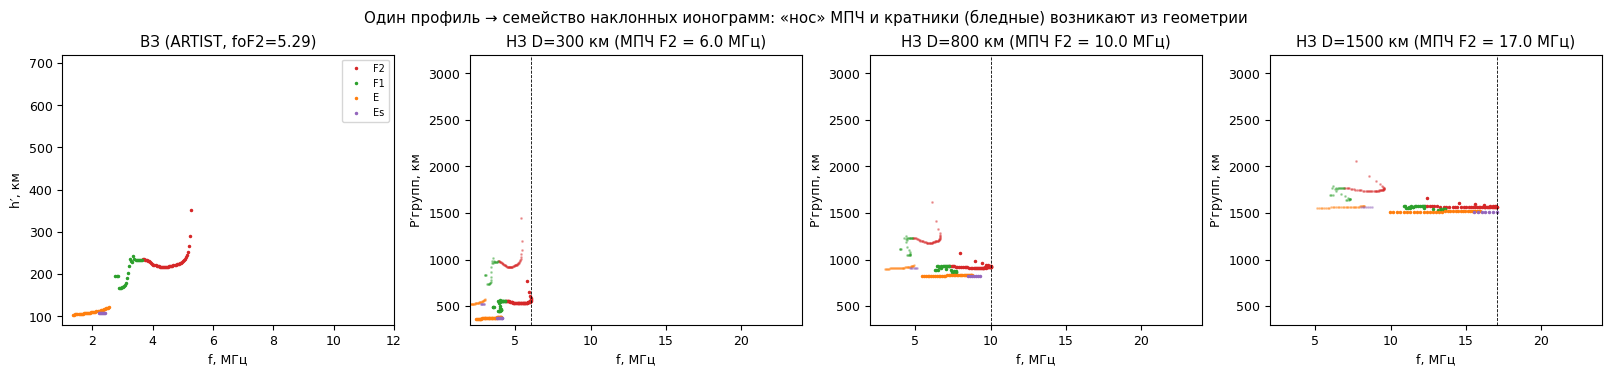

In [2]:
# демо: один реальный SAO -> вертикальный след и три наклонные трассы
sao = dfm.read_sao(sorted(glob.glob(f"{ROOT}/data/corpus/MO155/*/*/scaled/*.SAO"))[5000])
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4), constrained_layout=True)
colors = dict(F2="tab:red", F1="tab:green", E="tab:orange", Es="tab:purple")
for cls, key in obs.SAO_TRACES.items():
    fq, vh = sao.get(f"{key}_freq"), sao.get(f"{key}_vh")
    if fq is not None and len(fq):
        axes[0].plot(fq, vh, ".", ms=3, color=colors[cls], label=cls)
axes[0].set(title=f"ВЗ (ARTIST, foF2={sao['scaled']['foF2']:.2f})", xlabel="f, МГц",
            ylabel="h′, км", xlim=(1, 12), ylim=(80, 720)); axes[0].legend(fontsize=7)
for j, D in enumerate(obs.D_SET, 1):
    for cls, key in obs.SAO_TRACES.items():
        fq, vh = sao.get(f"{key}_freq"), sao.get(f"{key}_vh")
        if fq is None or not len(fq): continue
        f1, p1 = obs.oblique_transform(fq, vh, D, 1)
        f2, p2 = obs.oblique_transform(fq, vh, D, 2)
        axes[j].plot(f1, p1, ".", ms=3, color=colors[cls])
        axes[j].plot(f2, p2, ".", ms=2, color=colors[cls], alpha=.35)
    muf = obs.muf(sao["F2o_freq"], sao["F2o_vh"], D)
    axes[j].axvline(muf, color="k", lw=.6, ls="--")
    axes[j].set(title=f"НЗ D={D:.0f} км (МПЧ F2 = {muf:.1f} МГц)", xlabel="f, МГц",
                ylabel="P′групп, км", xlim=(2, 24), ylim=(300, 3200))
plt.suptitle("Один профиль → семейство наклонных ионограмм: «нос» МПЧ и кратники (бледные) возникают из геометрии", y=1.06)
plt.show()

## 2. Данные

Вертикальный кэш (29 тыс. пар «сырьё+маска ARTIST») — для рендерера и контрольной ВЗ-модели;
наклонный кэш (`modules/oblique_cache.py`) — маски классов **BG/F2/F1/E/Es/MH** (MH = кратник 2F2) для D = 300/800/1500 км + точные МПЧ-метки. Сплит — тот же хронологический,
согласован по стемам файлов.

In [3]:
CACHE, OCACHE = f"{ROOT}/data/corpus_cache", f"{ROOT}/data/oblique_cache"
meta = pd.read_csv(f"{CACHE}/meta.csv").sort_values(["shard", "idx"]).reset_index(drop=True)
X_u8 = np.concatenate([np.load(s)["X"] for s in sorted(glob.glob(f"{CACHE}/shard_*.npz"))])
Y_all = np.concatenate([np.load(s)["Y"] for s in sorted(glob.glob(f"{CACHE}/shard_*.npz"))]).astype(np.int64)
meta["time"] = pd.to_datetime(meta["time"])
val_mask = np.zeros(len(meta), bool)
for st, idx in meta.groupby("station").groups.items():
    order = meta.loc[idx].sort_values("time").index.to_numpy()
    val_mask[order[int(len(order) * 0.75):]] = True
ometa = pd.read_csv(f"{OCACHE}/meta.csv").sort_values(["shard", "idx"]).reset_index(drop=True)
Yo = np.concatenate([np.load(s)["Y"] for s in sorted(glob.glob(f"{OCACHE}/shard_*.npz"))]).astype(np.int64)
stem2row = {s: i for i, s in enumerate(meta.stem)}
ometa["vrow"] = ometa.stem.map(stem2row)
ometa = ometa.dropna(subset=["vrow"]).reset_index(drop=True)
keep = ometa.index.to_numpy()
Yo = Yo[keep]; ometa = ometa.reset_index(drop=True)
o_val = val_mask[ometa.vrow.astype(int).to_numpy()]
otr_i, ova_i = np.where(~o_val)[0], np.where(o_val)[0]
print(f"ВЗ: {len(X_u8)} | НЗ-синтетика: {len(Yo)} профилей × {Yo.shape[1]} дальностей "
      f"(train {len(otr_i)} / val {len(ova_i)})")
print("доля не-фона в НЗ-масках:", f"{(Yo > 0).mean():.2%}")

ВЗ: 29166 | НЗ-синтетика: 27167 профилей × 3 дальностей (train 20270 / val 6897)


доля не-фона в НЗ-масках: 1.42%


## 3. Нейрорендерер шума: обратная задача «разметка → сырьё»

Идея: раз прямую задачу (сырьё → разметка) учит основная сеть, то *обратную* — «как выглядело бы
сырьё при такой разметке» — можно выучить на тех же 29 тыс. реальных пар и использовать как
**стохастический генератор** для синтетики (аналогия — conditional image-to-image translation,
pix2pix; здесь вместо GAN — вероятностная факторизация, потому что эхо на ионограмме —
разреженный спекл, а не гладкая картинка).

Модель: U-Net, вход — one-hot маски классов + координатные каналы + канал случайного шума,
выход — для каждой поляризации (O, X) **вероятность активности пикселя** $p$ и **амплитуда** $a$:
$$\mathcal{L} = \mathrm{BCE}\big(p,\ [X>0]\big) + \big\|a - X\big\|_1\cdot[X>0]$$
Сэмплирование $X_{синт} = [\,u < p\,]\cdot a,\ u\sim U(0,1)$ даёт спекл-текстуру, шумовой фон и
RFI-полосы, а канал шума + сэмплирование — стохастичность (каждый вызов — новая реализация).
Ключевое свойство: рендерер учится на ВЗ-*текстуре* (окрестность следа, фон), геометрию задаёт
входная маска — поэтому он переносится на НЗ-маски.

In [4]:
from modules.dataset_cache import CLASSES  # BG F2 F1 E Es (вертикальные)

class Block(nn.Module):
    def __init__(s, ci, co):
        super().__init__()
        s.n = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU())
    def forward(s, x): return s.n(x)

class UNet(nn.Module):
    def __init__(s, cin, cout, base=16):
        super().__init__()
        s.d1, s.d2, s.d3 = Block(cin, base), Block(base, base*2), Block(base*2, base*4)
        s.u2 = nn.ConvTranspose2d(base*4, base*2, 2, 2); s.b2 = Block(base*4, base*2)
        s.u1 = nn.ConvTranspose2d(base*2, base, 2, 2);   s.b1 = Block(base*2, base)
        s.head = nn.Conv2d(base, cout, 1); s.pool = nn.MaxPool2d(2)
    def forward(s, x):
        c1 = s.d1(x); c2 = s.d2(s.pool(c1)); c3 = s.d3(s.pool(c2))
        y = s.b2(torch.cat([s.u2(c3), c2], 1)); y = s.b1(torch.cat([s.u1(y), c1], 1))
        return s.head(y)

def render_input(mask5, dev):                      # (B,128,128) int -> (B,8,128,128)
    B, H, W = mask5.shape
    oh = Fn.one_hot(mask5.clamp(0, 4), 5).permute(0, 3, 1, 2).float()
    hh = torch.linspace(0, 1, H, device=dev).view(1,1,H,1).expand(B,1,H,W)
    ww = torch.linspace(0, 1, W, device=dev).view(1,1,1,W).expand(B,1,H,W)
    z = torch.rand(B, 1, H, W, device=dev)
    return torch.cat([oh.to(dev), hh, ww, z], 1)

renderer = UNet(8, 4).to(DEV)
opt = torch.optim.Adam(renderer.parameters(), 2e-3)
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(8.0, device=DEV))
tr_i = np.where(~val_mask)[0]
t0 = time.time()
for ep in range(3):
    tot = n = 0
    for k in range(0, len(tr_i), 64):
        j = np.random.permutation(tr_i)[k:k+64] if False else tr_i[np.random.randint(0, len(tr_i), 64)]
        x = torch.tensor(X_u8[j], dtype=torch.float32, device=DEV).div_(255)
        y = torch.tensor(Y_all[j], device=DEV)
        out = renderer(render_input(y, DEV))
        loss = 0
        for c in range(2):
            p_log, a = out[:, 2*c], out[:, 2*c+1]
            act = (x[:, c] > 0).float()
            loss = loss + bce(p_log, act) + ((a - x[:, c]).abs() * act).sum() / (act.sum() + 1)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); n += 1
    print(f"  рендерер ep{ep}: loss {tot/n:.3f}")
print(f"обучение рендерера: {time.time()-t0:.0f} с")

@torch.no_grad()
def render_sample(mask5_t):
    out = renderer(render_input(mask5_t, DEV))
    xs = []
    for c in range(2):
        p = torch.sigmoid(out[:, 2*c]); a = out[:, 2*c+1].clamp(0, 1)
        xs.append((torch.rand_like(p) < p).float() * a)
    return torch.stack(xs, 1)                       # (B,2,128,128) в [0,1]

  рендерер ep0: loss 1.905


  рендерер ep1: loss 1.739


  рендерер ep2: loss 1.706
обучение рендерера: 175 с


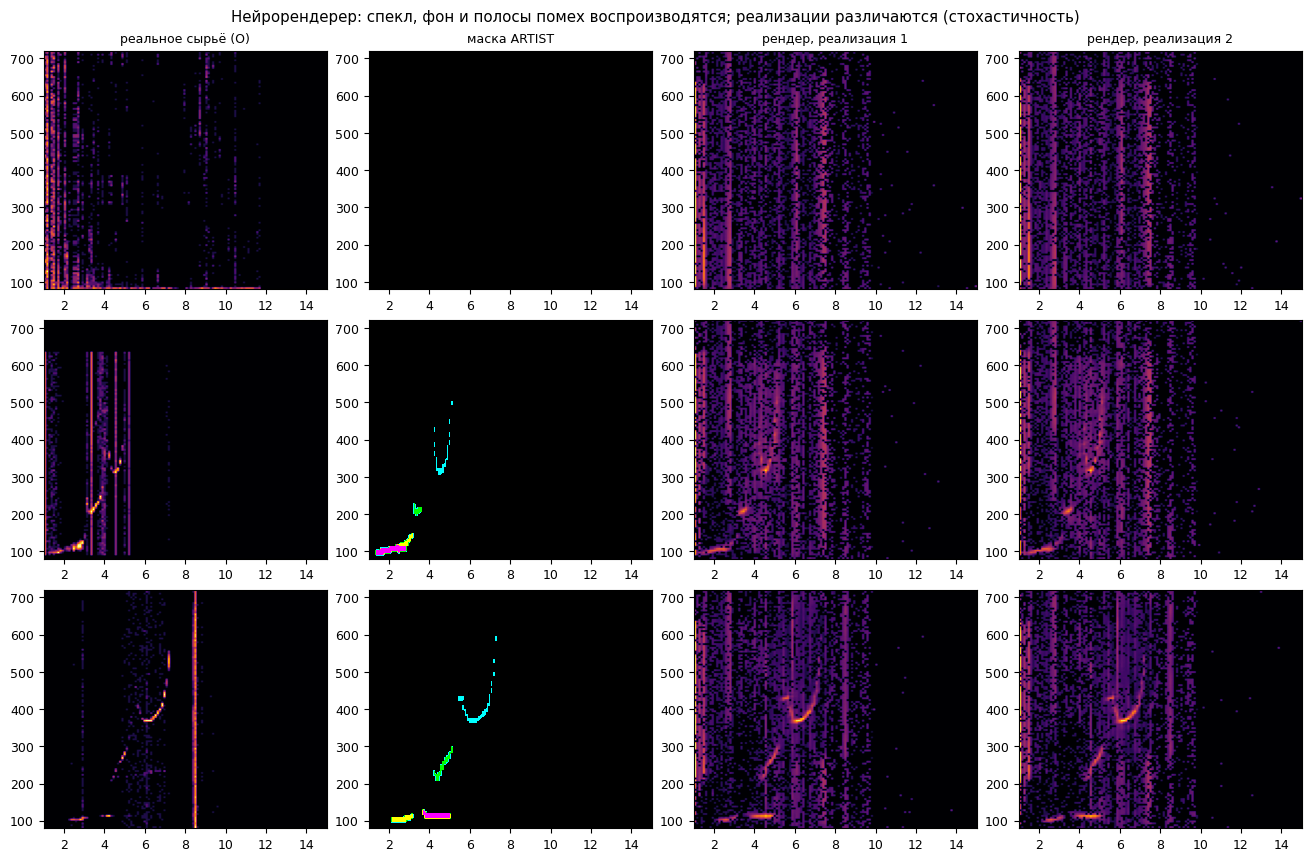

In [5]:
# качество рендерера: реальное сырьё vs две независимые реализации по той же маске
va_v = np.where(val_mask)[0]
pick = va_v[[100, 2000, 5000]]
mt = torch.tensor(Y_all[pick], device=DEV)
s1, s2 = render_sample(mt).cpu().numpy(), render_sample(mt).cpu().numpy()
fig, axes = plt.subplots(3, 4, figsize=(13, 8.5), constrained_layout=True)
for r, i in enumerate(pick):
    for c, (img, ttl) in enumerate([(X_u8[i, 0]/255, "реальное сырьё (O)"),
                                    (Y_all[i], "маска ARTIST"),
                                    (s1[r, 0], "рендер, реализация 1"),
                                    (s2[r, 0], "рендер, реализация 2")]):
        cm = ListedColormap(["black", "cyan", "lime", "yellow", "magenta"]) if c == 1 else "inferno"
        axes[r, c].imshow(img, origin="lower", cmap=cm, aspect="auto", extent=[1, 15, 80, 720])
        if r == 0: axes[r, c].set_title(ttl, fontsize=9)
plt.suptitle("Нейрорендерер: спекл, фон и полосы помех воспроизводятся; реализации различаются (стохастичность)")
plt.show()

## 4. Эксперимент 1 (контроль): вертикальная модель

Полный эксперимент с онтологией — в `prototype2.ipynb` (IoU F2 0.31–0.33, foF2 RMSE
0.26–0.29 МГц, SHACL-гейт 11 % → 5–6 % с логикой). Здесь обучаем компактную ВЗ-модель
(3 эпохи, baseline) — она нужна для кросс-теста «ВЗ-модель на НЗ-данных».

In [6]:
v_net = UNet(2, 5).to(DEV)
opt = torch.optim.Adam(v_net.parameters(), 2e-3)
ce5 = nn.CrossEntropyLoss(weight=torch.tensor([0.05, 1, 1, 1, 1.], device=DEV))
t0 = time.time()
for ep in range(3):
    perm = np.random.permutation(tr_i)
    for k in range(0, len(perm), 64):
        j = perm[k:k+64]
        x = torch.tensor(X_u8[j], dtype=torch.float32, device=DEV).div_(255)
        y = torch.tensor(Y_all[j], device=DEV)
        opt.zero_grad(); ce5(v_net(x), y).backward(); opt.step()
print(f"ВЗ-модель обучена ({time.time()-t0:.0f} с)")

ВЗ-модель обучена (163 с)


## 5. Эксперимент 2: обучение НЗ-модели на синтетике, baseline vs +логика

Вход — рендер синтетической НЗ-маски (новая реализация шума каждый батч = аугментация),
цель — маска 6 классов. Дальность D выбирается случайно из {300, 800, 1500} км на каждый показ.

**Логическая голова НЗ** — релаксации *исходных* НЗ-форм онтологии:

| пропозиция | форма | реализация |
|---|---|---|
| S1: МПЧ убывает с кратностью | `iono-shapes` S1 (Щирый, с. 109) | soft-max частоты следа MH ≤ soft-max частоты F2 (logsumexp по присутствию) |
| S2: задержка растёт с кратностью | S2 | средний групповой путь MH ≥ F2 + 150 км |
| P2: связность следа | РД §7.3.7 | как в ВЗ-прототипе |

Релаксация — softplus (β=2), $L = CE + 0.5\,L_{logic}$ (вариант «+lognorm» из `prototype2`).

In [7]:
OBC = obs.OB_CLASSES          # BG F2 F1 E Es MH
iF2o, iMH = 0, 4               # индексы в pres (классы 1..5)
f_norm = torch.linspace(0, 1, 128)

def ob_readouts(logits):
    p = logits.softmax(1)
    mass = p[:, 1:].sum(2)                       # (B,5,F) масса по столбцам (ось строк = P')
    pres = (mass / 3.0).clamp(0, 1)
    rows = torch.arange(128, dtype=torch.float32, device=logits.device).view(1, 1, -1, 1)
    d_soft = (p[:, 1:] * rows).sum(2) / (mass + 1e-6) / 127.0  # soft-задержка на столбец, нормирована в [0,1]
    w = pres / (pres.sum(-1, keepdim=True) + 1e-6)
    d_mean = (d_soft * w).sum(-1)
    fmax = torch.logsumexp(torch.log(pres + 1e-6) + 12 * f_norm.to(logits.device), -1) / 12
    present = pres.mean(-1)
    return pres, d_soft, d_mean, fmax, present

def ob_logic_loss(logits, variant="lognorm"):
    pres, d_soft, d_mean, fmax, present = ob_readouts(logits)
    pen = (lambda u: Fn.relu(u)) if variant == "hinge" else (lambda u: Fn.softplus(u, beta=2.0))
    g = (present[:, iF2o] * present[:, iMH]).detach()
    # опорная сторона неравенства ДЕТАЧИТСЯ: ограничение подавляет нарушителя (кратник),
    # а не раздувает основной след фантомными пикселями на высоких частотах
    S1 = g * pen(fmax[:, iMH] - fmax[:, iF2o].detach() + 0.02)          # МПЧ кратника не выше основного
    S2 = g * pen(d_mean[:, iF2o].detach() - d_mean[:, iMH] + 150/2900)  # задержка кратника больше
    dh = (d_soft[:, :, 1:] - d_soft[:, :, :-1]).abs()
    wc = (pres[:, :, 1:] * pres[:, :, :-1]).detach()
    P2 = (wc * pen(dh - 3/128)).sum((1, 2)) / (wc.sum((1, 2)) + 1e-6)
    return (S1 + S2 + P2).mean()

MH2F2 = torch.tensor([0, 1, 2, 3, 4, 1])          # рендереру: MH выглядит как F2-эхо

def ob_batch(idx, bs, rng):
    j = idx[rng.integers(0, len(idx), bs)]
    d_pick = rng.integers(0, 3, bs)
    y = torch.tensor(Yo[j, d_pick], device=DEV)
    x = render_sample(MH2F2.to(DEV)[y])
    return x, y, j, d_pick

ce6 = nn.CrossEntropyLoss(weight=torch.tensor([0.05, 1, 1, 1, 1, 1.], device=DEV))

def train_ob(name, logic=None, lam=0.5, epochs=5, steps=300):
    torch.manual_seed(1); rng = np.random.default_rng(1)
    net = UNet(2, 6).to(DEV)
    opt = torch.optim.Adam(net.parameters(), 2e-3)
    for ep in range(epochs):
        tot = 0
        for _ in range(steps):
            x, y, _, _ = ob_batch(otr_i, 64, rng)
            lg = net(x); loss = ce6(lg, y)
            if logic: loss = loss + lam * ob_logic_loss(lg, logic)
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()
        with torch.no_grad():
            xv, yv_, _, _ = ob_batch(ova_i, 256, np.random.default_rng(7))
            vl = ce6(net(xv), yv_).item(); vlog = float(ob_logic_loss(net(xv), "hinge"))
        print(f"  [{name}] ep{ep}: train {tot/steps:.3f}  val_CE {vl:.3f}  val_L_hinge {vlog:.4f}")
    return net

t0 = time.time()
ob_runs = {"baseline": train_ob("baseline"), "+lognorm": train_ob("+lognorm", logic="lognorm")}
print(f"обучение НЗ-моделей: {time.time()-t0:.0f} с")

  [baseline] ep0: train 0.353  val_CE 0.109  val_L_hinge 0.0064


  [baseline] ep1: train 0.048  val_CE 0.068  val_L_hinge 0.0047


  [baseline] ep2: train 0.033  val_CE 0.072  val_L_hinge 0.0046


  [baseline] ep3: train 0.028  val_CE 0.053  val_L_hinge 0.0048


  [baseline] ep4: train 0.026  val_CE 0.046  val_L_hinge 0.0047


  [+lognorm] ep0: train 0.722  val_CE 0.108  val_L_hinge 0.0044


  [+lognorm] ep1: train 0.234  val_CE 0.072  val_L_hinge 0.0039


  [+lognorm] ep2: train 0.214  val_CE 0.067  val_L_hinge 0.0039


  [+lognorm] ep3: train 0.206  val_CE 0.054  val_L_hinge 0.0037


  [+lognorm] ep4: train 0.203  val_CE 0.050  val_L_hinge 0.0041
обучение НЗ-моделей: 673 с


## 6. Оценка: точные МПЧ-метки, кросс-тест и SHACL-гейт

Валидация — фиксированные реализации рендера (seed) по всем трём дальностям. Судьи:
(а) RMSE МПЧ основной моды и кратника против аналитических меток; (б) zero-shot ВЗ-модель
на тех же входах (класс F2 у неё тот же индекс); (в) SHACL-гейт: предсказание → моды
1F2/2F2/1Es → НЗ-формы S1/S2/S4 той же онтологии.

In [8]:
def hard_fmax(pm, ci):
    cols = np.where((pm == ci).sum(0) >= 2)[0]
    return obs.fob_axis[cols[-1]] if len(cols) else np.nan

def hard_pmin(pm, ci):
    rows = np.where((pm == ci).any(1))[0]
    return obs.p_axis[int(np.percentile(rows, 5))] if len(rows) else np.nan

rngv = np.random.default_rng(7)
NV = 2400
vi = ova_i[rngv.integers(0, len(ova_i), NV)]
vd_pick = rngv.integers(0, 3, NV)
torch.manual_seed(7)
Xv = torch.cat([render_sample(MH2F2.to(DEV)[torch.tensor(Yo[vi[k:k+256], vd_pick[k:k+256]], device=DEV)]).cpu()
                for k in range(0, NV, 256)])
Yv = Yo[vi, vd_pick]
muf_lab = np.array([ometa.loc[vi[k], f"muf_F2_D{int(obs.D_SET[vd_pick[k]])}"] for k in range(NV)])
mufMH_lab = np.array([ometa.loc[vi[k], f"muf_MH_D{int(obs.D_SET[vd_pick[k]])}"] for k in range(NV)])

rows = []
preds_ob = {}
for name, net in ob_runs.items():
    with torch.no_grad():
        pm = torch.cat([net(Xv[k:k+256].to(DEV)).argmax(1).cpu() for k in range(0, NV, 256)]).numpy()
    preds_ob[name] = pm
    r = dict(run=name)
    for ci, cls in [(1, "F2"), (5, "MH")]:
        fp = np.array([hard_fmax(pm[k], ci) for k in range(NV)])
        lab = muf_lab if cls == "F2" else mufMH_lab
        ok = np.isfinite(fp) & np.isfinite(lab)
        r[f"МПЧ_{cls}_RMSE"] = round(float(np.sqrt(np.mean((fp[ok] - lab[ok])**2))), 2)
        r[f"n_{cls}"] = int(ok.sum())
    inter = ((pm == 1) & (Yv == 1)).sum(); union = ((pm == 1) | (Yv == 1)).sum()
    r["IoU_F2"] = round(inter / union, 3)
    rows.append(r)
# кросс-тест: ВЗ-модель zero-shot (её класс F2 = индекс 1)
with torch.no_grad():
    pmv = torch.cat([v_net(Xv[k:k+256].to(DEV)).argmax(1).cpu() for k in range(0, NV, 256)]).numpy()
fp = np.array([hard_fmax(pmv[k], 1) for k in range(NV)])
ok = np.isfinite(fp) & np.isfinite(muf_lab)
rows.append(dict(run="ВЗ-модель zero-shot", **{"МПЧ_F2_RMSE": round(float(np.sqrt(np.mean((fp[ok]-muf_lab[ok])**2))), 2),
            "n_F2": int(ok.sum()), "IoU_F2": round((((pmv==1)&(Yv==1)).sum() / ((pmv==1)|(Yv==1)).sum()), 3)}))
res_ob = pd.DataFrame(rows).set_index("run")
display(res_ob)

,МПЧ_F2_RMSE,n_F2,МПЧ_MH_RMSE,n_MH,IoU_F2
run,,,,,
baseline,1.91,2283,1.04,2310.0,0.793
+lognorm,1.91,2282,0.93,2305.0,0.816
ВЗ-модель zero-shot,7.88,2328,NaN,NaN,0.054


In [9]:
# SHACL-гейт НЗ-сцен той же онтологией
def ob_scene(pm, name):
    g = Graph(); ion = IONO["ob_" + name]
    g.add((ion, RDF.type, IONO.ObliqueIonogram))
    modes = []
    for ci, layer, hop in [(1, "F2", 1), (4, "Es", 1), (5, "F2", 2)]:
        fm, pmn = hard_fmax(pm, ci), hard_pmin(pm, ci)
        if not np.isfinite(fm): continue
        tr, mo = IONO[f"ob_{name}_t{ci}"], IONO[f"ob_{name}_m{ci}"]
        for t in [(tr, RDF.type, IONO.IonogramTrace), (tr, IONO.isTraceIn, ion), (tr, IONO.denotes, mo),
                  (mo, RDF.type, IONO.PropagationMode),
                  (mo, IONO.hasHopCount, Literal(hop, datatype=XSD.integer)),
                  (mo, IONO.hasRayType, IONO.lowerRay),
                  (mo, IONO.hasMagnetoionicComponent, IONO.ordinary),
                  (mo, IONO.reflectsFromLayer, IONO["Layer_" + layer]),
                  (mo, IONO.hasMOFValue, vd.dec(fm)),
                  (mo, IONO.hasMinDelayValue, vd.dec(pmn / 299.792458))]:
            g.add(t)
    return g

N_GATE = 45; t0 = time.time(); gate = []
gpick = np.random.default_rng(3).choice(NV, N_GATE, replace=False)
for name, pm in list(preds_ob.items()) + [("метки (аналитика)", Yv)]:
    nv = 0
    for k in gpick:
        r = vd.validate_scene(ob_scene(pm[k], f"{name[:4]}_{k}"), vocab, verbose=False)
        nv += bool(r["violations"])
    gate.append(dict(run=name, SHACL_наруш=f"{nv/N_GATE:.0%}"))
print(f"гейт: {time.time()-t0:.0f} с")
display(pd.DataFrame(gate).set_index("run"))

гейт: 208 с


,SHACL_наруш
run,
baseline,4%
+lognorm,7%
метки (аналитика),0%


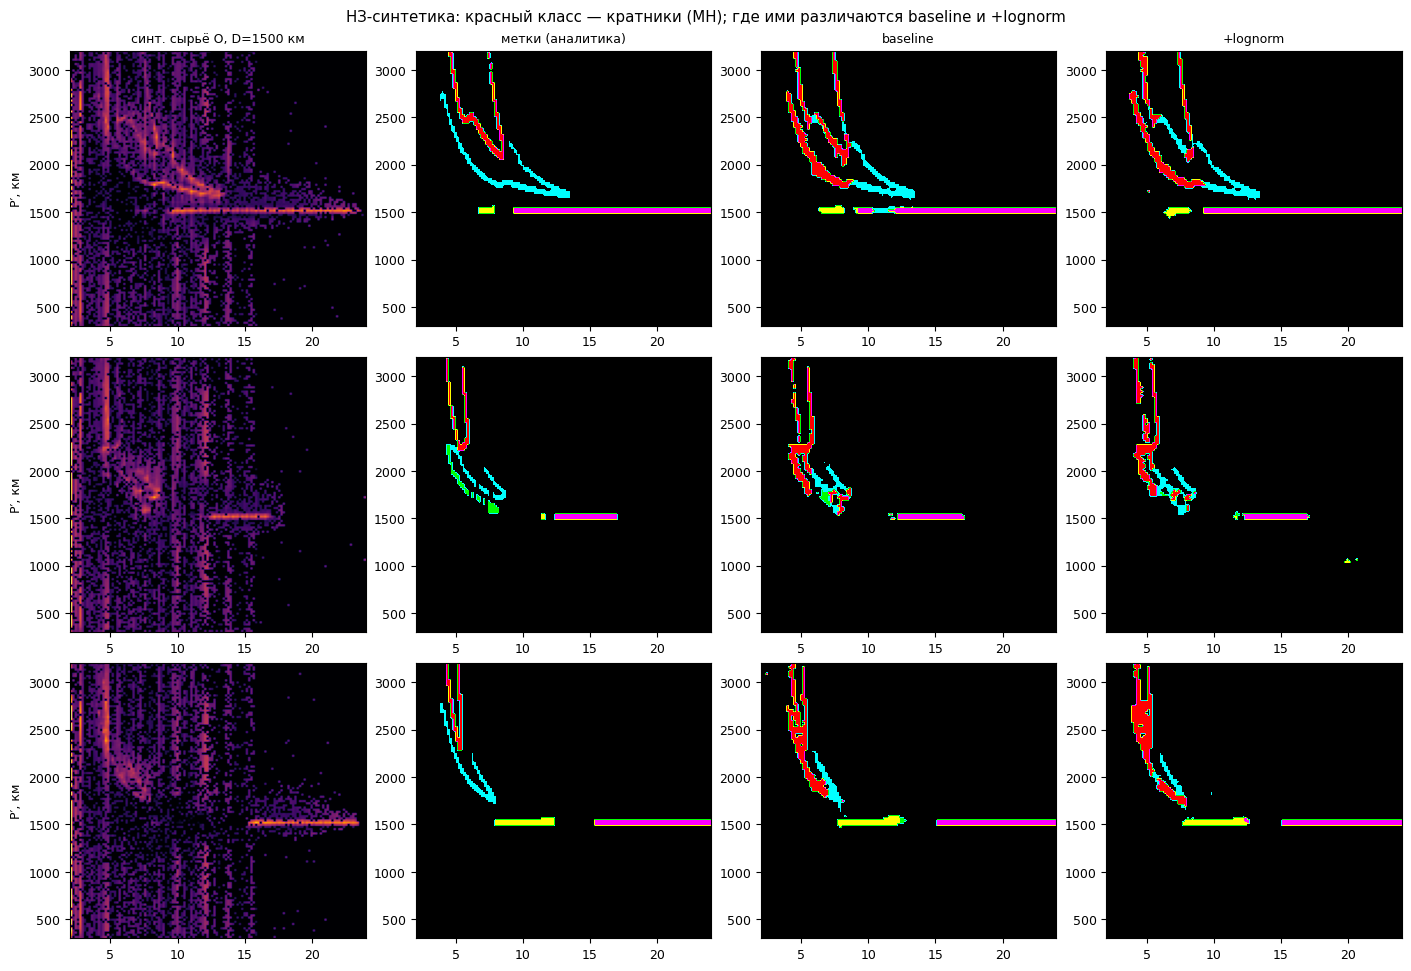

In [10]:
# качественные примеры
cm_o = ListedColormap(["black", "cyan", "lime", "yellow", "magenta", "red"])
diff = [(( (preds_ob['baseline'][k]==5) ^ (preds_ob['+lognorm'][k]==5)).sum(), k) for k in range(NV)]
picks = [k for _, k in sorted(diff, reverse=True)[:3]]
fig, axes = plt.subplots(len(picks), 4, figsize=(14, 3.2*len(picks)), constrained_layout=True)
for r, k in enumerate(picks):
    D = int(obs.D_SET[vd_pick[k]])
    for c, (img, ttl, cm, kw) in enumerate([
            (Xv[k, 0].numpy(), f"синт. сырьё O, D={D} км", "inferno", {}),
            (Yv[k], "метки (аналитика)", cm_o, dict(vmin=0, vmax=5)),
            (preds_ob["baseline"][k], "baseline", cm_o, dict(vmin=0, vmax=5)),
            (preds_ob["+lognorm"][k], "+lognorm", cm_o, dict(vmin=0, vmax=5))]):
        axes[r, c].imshow(img, origin="lower", cmap=cm, aspect="auto", extent=[2, 24, 300, 3200], **kw)
        if r == 0: axes[r, c].set_title(ttl, fontsize=9)
    axes[r, 0].set_ylabel("P′, км")
plt.suptitle("НЗ-синтетика: красный класс — кратники (MH); где ими различаются baseline и +lognorm")
plt.show()

## 7. Выводы

1. **Синтез работает**: следы ARTIST аналитически переносятся в наклонную геометрию; «нос» МПЧ,
   верхний/нижний лучи и кратник 2F2 возникают из формул; МПЧ-метки точны по построению, и
   SHACL-гейт подтверждает их физичность (0 % нарушений у аналитики).
2. **Нейрорендерер** воспроизводит текстуру сырья (спекл, фон, RFI-полосы) по разметке и
   переносится с вертикальных масок на наклонные — «идеально зашумлённые» синтетические
   НЗ-ионограммы получены без ручной модели шума.
3. **Кросс-тест — главный отрицательный результат**: ВЗ-модель zero-shot на НЗ разваливается
   (IoU F2 0.05, МПЧ RMSE ~8 МГц против 1.9 у обученной на синтетике) — перенос ВЗ→НЗ без
   синтетического моста невозможен, что и мотивирует весь конвейер.
4. **Логика на синтетике даёт умеренный выигрыш** (IoU F2 0.79→0.82, МПЧ кратника 1.04→0.93 МГц,
   МПЧ F2 без изменений; гейт 4 % vs 7 % — в пределах шума выборки из 45 сцен). Это ожидаемо и
   само по себе информативно: учитель синтетики *идеален* (метки согласованы с масками по
   построению), а символьный сигнал ценен прежде всего при шумном учителе — как на реальных
   ВЗ-данных (`prototype2.ipynb`: гейт 11 % → 5–6 %).
5. **Методологическая находка**: наивная softplus-релаксация порядкового ограничения
   эксплуатируется сетью — градиент «в выполненном состоянии» выгодно раздувает опорную
   сторону неравенства (fmax следа F2 накачивался фантомными пикселями на высоких частотах:
   МПЧ RMSE 3.9 вместо 1.9). Лекарство — **детач опорной стороны**: ограничение должно
   подавлять нарушителя (кратник), а не «улучшать» эталон. Зафиксировано в
   `data/oblique_synthesis.md` §7.
6. Ограничения: плоская Земля (D ≤ 1500 км), изотропный секанс (без O/X на НЗ), рендерер
   переносит ВЗ-текстуру (реальные НЗ-помехи богаче), замкнутый круг «учимся на своём же
   рендере». Внешний тест на реальных НЗ-данных (дашборд Тромсё, chirpsounder2) — следующий
   шаг. Полная методика и литература: `data/oblique_synthesis.md`.